In [5]:
import json
import pandas as pd
import os

In [6]:

resultados = []

pasta = "/content"

for arquivo in os.listdir(pasta):

    if arquivo.endswith(".json"):

        with open(os.path.join(pasta, arquivo), "r") as f:

            dados = json.load(f)

            resultados.append(dados)

df_displasia = pd.DataFrame(resultados)

df_displasia

""


In [7]:
import pandas as pd

df_displasia = pd.read_csv("/content/resultados_consolidados.csv")

df_displasia

,seed,dataset,model,training_mode,augmentation,acc_test,f1_macro_test,f1_weighted_test,num_params,gflops,best_epoch,val_acc_best
0,42,Displastia,convnextv2_atto,FS,sim,0.847826,0.844219,0.844219,3.368362,0.547029,20,0.921053
1,123,Displastia,convnextv2_atto,FS,sim,0.934783,0.934504,0.934504,3.368362,0.547029,28,0.947368
2,2025,Displastia,convnextv2_atto,FS,sim,0.956522,0.956439,0.956439,3.368362,0.547029,21,0.947368
3,42,Displastia,convnextv2_atto,FS,nao,0.869565,0.869318,0.869318,3.368362,0.547029,8,0.868421
4,123,Displastia,convnextv2_atto,FS,nao,0.934783,0.934752,0.934752,3.368362,0.547029,8,0.868421
5,2025,Displastia,convnextv2_atto,FS,nao,0.891304,0.891253,0.891253,3.368362,0.547029,17,0.894737
6,42,Displastia,convnextv2_atto,PT-FC,sim,0.956522,0.956439,0.956439,3.368362,0.547029,45,0.947368
7,123,Displastia,convnextv2_atto,PT-FC,sim,0.913043,0.912879,0.912879,3.368362,0.547029,26,0.921053
8,2025,Displastia,convnextv2_atto,PT-FC,sim,0.913043,0.913043,0.913043,3.368362,0.547029,48,0.973684
9,42,Displastia,convnextv2_atto,PT-FC,nao,0.956522,0.956439,0.956439,3.368362,0.547029,30,0.921053


**Exploration**

In [8]:
df_displasia.head()

,seed,dataset,model,training_mode,augmentation,acc_test,f1_macro_test,f1_weighted_test,num_params,gflops,best_epoch,val_acc_best
0,42,Displastia,convnextv2_atto,FS,sim,0.847826,0.844219,0.844219,3.368362,0.547029,20,0.921053
1,123,Displastia,convnextv2_atto,FS,sim,0.934783,0.934504,0.934504,3.368362,0.547029,28,0.947368
2,2025,Displastia,convnextv2_atto,FS,sim,0.956522,0.956439,0.956439,3.368362,0.547029,21,0.947368
3,42,Displastia,convnextv2_atto,FS,nao,0.869565,0.869318,0.869318,3.368362,0.547029,8,0.868421
4,123,Displastia,convnextv2_atto,FS,nao,0.934783,0.934752,0.934752,3.368362,0.547029,8,0.868421


In [9]:
df_displasia.shape #Linhas / Coluna

(37, 12)

In [4]:
df_displasia.columns

Index(['seed', 'dataset', 'model', 'training_mode', 'augmentation', 'acc_test',
       'f1_macro_test', 'f1_weighted_test', 'num_params', 'gflops',
       'best_epoch', 'val_acc_best'],
      dtype='object')

In [5]:
df_displasia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   seed              37 non-null     int64  
 1   dataset           37 non-null     object 
 2   model             37 non-null     object 
 3   training_mode     37 non-null     object 
 4   augmentation      37 non-null     object 
 5   acc_test          37 non-null     float64
 6   f1_macro_test     37 non-null     float64
 7   f1_weighted_test  37 non-null     float64
 8   num_params        37 non-null     float64
 9   gflops            37 non-null     float64
 10  best_epoch        37 non-null     int64  
 11  val_acc_best      37 non-null     float64
dtypes: float64(6), int64(2), object(4)
memory usage: 3.6+ KB


In [10]:
df_displasia.describe()

,seed,acc_test,f1_macro_test,f1_weighted_test,num_params,gflops,best_epoch,val_acc_best
count,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000
mean,711.405405,0.905993,0.895889,0.895889,6.015245,0.967874,24.756757,0.931010
std,923.254613,0.113314,0.148985,0.148985,2.611823,0.415271,16.071724,0.050143
min,42.000000,0.500000,0.333333,0.333333,3.368362,0.547029,2.000000,0.842105
25%,42.000000,0.891304,0.891253,0.891253,3.368362,0.547029,8.000000,0.894737
50%,123.000000,0.934783,0.934504,0.934504,8.522818,1.366570,26.000000,0.921053
75%,2025.000000,0.956522,0.956439,0.956439,8.522818,1.366570,38.000000,0.973684
max,2025.000000,1.000000,1.000000,1.000000,8.522818,1.366570,50.000000,1.000000


In [11]:
df_displasia["model"].unique() #Quais modelos existem

array(['convnextv2_atto', 'convnextv2_pico'], dtype=object)

In [12]:
df_displasia["training_mode"].unique() #Quais modos existem

array(['FS', 'PT-FC', 'PT-ALL'], dtype=object)

In [13]:
df_displasia["seed"].unique() #Quais Seeds

array([  42,  123, 2025])

In [14]:
df_displasia["augmentation"].value_counts() #Balanceamento Augmentation

,count
augmentation,
nao,19
sim,18


In [15]:
#Melhor Resultado
df_displasia.sort_values("acc_test", ascending=False)

,seed,dataset,model,training_mode,augmentation,acc_test,f1_macro_test,f1_weighted_test,num_params,gflops,best_epoch,val_acc_best
17,2025,Displastia,convnextv2_atto,PT-ALL,nao,1.000000,1.000000,1.000000,3.368362,0.547029,3,1.000000
13,123,Displastia,convnextv2_atto,PT-ALL,sim,1.000000,1.000000,1.000000,3.368362,0.547029,5,1.000000
14,2025,Displastia,convnextv2_atto,PT-ALL,sim,1.000000,1.000000,1.000000,3.368362,0.547029,3,1.000000
15,42,Displastia,convnextv2_atto,PT-ALL,nao,1.000000,1.000000,1.000000,3.368362,0.547029,4,1.000000
12,42,Displastia,convnextv2_atto,PT-ALL,sim,1.000000,1.000000,1.000000,3.368362,0.547029,5,1.000000
24,42,Displastia,convnextv2_pico,PT-FC,sim,0.978261,0.978251,0.978251,8.522818,1.366570,39,0.868421
16,123,Displastia,convnextv2_atto,PT-ALL,nao,0.978261,0.978251,0.978251,3.368362,0.547029,2,1.000000
11,2025,Displastia,convnextv2_atto,PT-FC,nao,0.956522,0.956522,0.956522,3.368362,0.547029,24,0.973684
6,42,Displastia,convnextv2_atto,PT-FC,sim,0.956522,0.956439,0.956439,3.368362,0.547029,45,0.947368
2,2025,Displastia,convnextv2_atto,FS,sim,0.956522,0.956439,0.956439,3.368362,0.547029,21,0.947368


In [16]:
#Pior Resultado
df_displasia.sort_values("acc_test", ascending=True)

,seed,dataset,model,training_mode,augmentation,acc_test,f1_macro_test,f1_weighted_test,num_params,gflops,best_epoch,val_acc_best
34,42,Displastia,convnextv2_pico,PT-ALL,nao,0.500000,0.333333,0.333333,8.522818,1.366570,4,0.842105
33,42,Displastia,convnextv2_pico,PT-ALL,nao,0.500000,0.333333,0.333333,8.522818,1.366570,4,0.842105
35,123,Displastia,convnextv2_pico,PT-ALL,nao,0.695652,0.664583,0.664583,8.522818,1.366570,13,0.894737
0,42,Displastia,convnextv2_atto,FS,sim,0.847826,0.844219,0.844219,3.368362,0.547029,20,0.921053
29,2025,Displastia,convnextv2_pico,PT-FC,nao,0.847826,0.847754,0.847754,8.522818,1.366570,50,0.921053
3,42,Displastia,convnextv2_atto,FS,nao,0.869565,0.869318,0.869318,3.368362,0.547029,8,0.868421
31,123,Displastia,convnextv2_pico,PT-ALL,sim,0.891304,0.890005,0.890005,8.522818,1.366570,37,1.000000
5,2025,Displastia,convnextv2_atto,FS,nao,0.891304,0.891253,0.891253,3.368362,0.547029,17,0.894737
21,42,Displastia,convnextv2_pico,FS,nao,0.891304,0.890840,0.890840,8.522818,1.366570,17,0.868421
26,2025,Displastia,convnextv2_pico,PT-FC,sim,0.891304,0.891253,0.891253,8.522818,1.366570,45,0.868421


# Valores Medios

In [17]:
df_displasia.groupby("training_mode")["acc_test"].mean() #Media por modo

,acc_test
training_mode,
FS,0.918478
PT-ALL,0.874582
PT-FC,0.927536


In [18]:
df_displasia.groupby("model")["acc_test"].mean() #Media por Modelo

,acc_test
model,
convnextv2_atto,0.946860
convnextv2_pico,0.867277


In [19]:
df_displasia.groupby("augmentation")["acc_test"].mean() #Augmentation foi relevante?

,acc_test
augmentation,
nao,0.875286
sim,0.938406


# Relatorio 1 - Análise Inicial dos Dados

O DataFrame consolidado referente ao dataset Displasia apresentou um total de 37 experimentos distribuídos em 12 atributos distintos. Durante a análise exploratória dos dados, não foram identificados valores ausentes ou inconsistências, indicando que os resultados foram armazenados corretamente e que o conjunto encontra-se íntegro para análise estatística e comparativa.

Os experimentos foram realizados utilizando duas arquiteturas de redes neurais convolucionais:

* ConvNeXtV2 Atto
* ConvNeXtV2 Pico

Além disso, foram avaliados três modos distintos de treinamento:

* FS (From Scratch)
* PT-FC (Pré-treinado com Backbone Congelado)
* PT-ALL (Pré-treinado com Fine-Tuning Completo)

Cada configuração experimental foi executada utilizando três seeds diferentes (42, 123 e 2025), com o objetivo de reduzir possíveis influências da aleatoriedade no processo de treinamento e permitir uma avaliação mais confiável da estabilidade dos modelos.

**Data Augmentation**

A variável augmentation representa a utilização ou não de técnicas de aumento artificial de dados durante o treinamento do modelo.

Nos experimentos:

* sim → indica que técnicas de Data Augmentation foram utilizadas;
* não → indica que o treinamento ocorreu utilizando apenas as imagens originais.

As técnicas de Data Augmentation têm como objetivo aumentar artificialmente a variabilidade do conjunto de treinamento por meio de pequenas transformações nas imagens, como rotações, espelhamentos e redimensionamentos. Isso permite que o modelo seja exposto a diferentes variações dos mesmos padrões visuais, reduzindo o risco de overfitting e aumentando a capacidade de generalização.

Durante a análise dos experimentos, observou-se uma distribuição praticamente equilibrada entre execuções com e sem augmentation:

* Sem augmentation: 19 experimentos
* Com augmentation: 18 experimentos

Essa distribuição é considerada quase balanceada porque existe uma quantidade muito semelhante de experimentos nos dois cenários. Isso é importante para evitar comparações enviesadas, garantindo que ambos os grupos possuam representatividade semelhante durante a análise estatística.

**Resultados Augmentation**

Os resultados mostraram que os experimentos com Data Augmentation apresentaram desempenho médio superior aos experimentos sem augmentation.

As médias observadas foram:

* Sem augmentation: 0.875
* Com augmentation: 0.938

Essa diferença indica que o uso de augmentation contribuiu positivamente para o desempenho dos modelos no dataset Displasia.

Esse comportamento pode ser explicado pelo fato de que o augmentation aumenta artificialmente a diversidade das imagens de treinamento, permitindo que a rede neural aprenda padrões mais generalizáveis e menos dependentes de características específicas do conjunto original.

Além disso, técnicas de augmentation ajudam a reduzir problemas de overfitting, especialmente em datasets relativamente pequenos, como frequentemente ocorre em aplicações de imagens médicas e histológicas.

**Comparação entre as Arquiteturas**

Durante a análise dos resultados obtidos no dataset Displasia, observou-se uma diferença significativa de desempenho entre as arquiteturas ConvNeXtV2 Atto e ConvNeXtV2 Pico.

As médias de acurácia observadas foram:

* ConvNeXtV2 Atto: 0.946
* ConvNeXtV2 Pico: 0.867

Os resultados indicam que a arquitetura ConvNeXtV2 Atto apresentou desempenho superior na tarefa de classificação histológica quando comparada à ConvNeXtV2 Pico.

De forma simplificada, isso significa que a arquitetura Atto conseguiu identificar e diferenciar melhor os padrões presentes nas imagens do dataset. Em problemas de visão computacional médica, pequenas diferenças visuais entre classes podem ser extremamente importantes, e arquiteturas mais adequadas conseguem extrair essas características de maneira mais eficiente.

Além disso, os resultados sugerem que a arquitetura Pico pode ter apresentado menor capacidade de generalização para este problema específico. Embora ambas pertençam à mesma família de modelos, pequenas diferenças estruturais podem impactar diretamente a capacidade de aprendizado da rede neural.

**Comparação entre os modos**

A análise dos diferentes modos de treinamento apresentou resultados relevantes para a interpretação do comportamento dos modelos no dataset Displasia.

As médias de acurácia observadas foram:

* FS (From Scratch): 0.918
* PT-FC (Pré-treinado com Backbone Congelado): 0.927
* PT-ALL (Fine-Tuning Completo): 0.874

Os resultados mostram que o modo PT-FC apresentou o melhor desempenho médio entre os três modos avaliados.

Inicialmente, esperava-se que o modo PT-ALL apresentasse os melhores resultados, uma vez que ele permite o ajuste completo de todas as camadas do modelo. Entretanto, os experimentos demonstraram um comportamento diferente do esperado.

Uma possível explicação para esse resultado é a ocorrência de overfitting durante o fine-tuning completo. Nesse cenário, o modelo passa a se adaptar excessivamente aos dados de treinamento, reduzindo sua capacidade de generalização para imagens não vistas anteriormente.

Esse comportamento é relativamente comum em aplicações médicas e histológicas, especialmente quando os datasets possuem tamanho limitado. Como o modo PT-ALL ajusta todas as camadas da rede neural simultaneamente, o modelo pode acabar aprendendo detalhes muito específicos do conjunto de treino, em vez de aprender padrões mais generalizáveis.

Além disso, alguns experimentos apresentaram resultados consideravelmente inferiores, como acurácias próximas de 0.500 e 0.695, principalmente nas configurações envolvendo ConvNeXtV2 Pico com PT-ALL sem augmentation. Esses resultados indicam possíveis problemas de estabilidade durante o treinamento, além de sugerirem dificuldades de convergência do modelo nesse cenário específico.

**Características Gerais do Dataset**

Os resultados obtidos sugerem que o dataset Displasia apresenta uma tarefa de classificação relativamente bem definida para algumas configurações experimentais.

Diversos experimentos alcançaram acurácia igual a 1.000, indicando que o modelo conseguiu classificar corretamente todas as imagens do conjunto de teste em determinadas execuções.

Esse comportamento pode indicar:

* boa separação visual entre as classes;
* presença de padrões histológicos relativamente distintos;
* menor complexidade da tarefa binária em comparação com problemas multiclasse.

Entretanto, também foram identificados resultados significativamente inferiores em algumas execuções específicas, caracterizando a presença de outliers experimentais.

Os valores próximos de 0.500 e 0.695 merecem atenção especial, pois impactam negativamente as médias gerais, principalmente no modo PT-ALL. Essas variações sugerem que determinadas combinações de arquitetura, modo de treinamento e augmentation podem apresentar maior instabilidade durante o processo de aprendizado.

**Análise de Complexidade Computacional**

A análise dos parâmetros e da complexidade computacional dos modelos também apresentou resultados interessantes.

Observou-se que a arquitetura ConvNeXtV2 Atto apresentou menor quantidade de parâmetros e menor custo computacional em GFLOPs quando comparada à ConvNeXtV2 Pico.

Mesmo sendo uma arquitetura mais leve, a ConvNeXtV2 Atto obteve desempenho superior nos experimentos realizados.

Esse resultado é relevante, pois demonstra que modelos menores nem sempre apresentam desempenho inferior. Em alguns cenários, arquiteturas mais compactas podem alcançar melhores resultados devido à maior estabilidade de treinamento e menor tendência ao overfitting.

Além disso, modelos mais leves apresentam vantagens práticas importantes, como menor custo computacional, menor consumo de memória e maior facilidade de implantação em ambientes com recursos limitados.

# Etapa 2 - Graficos

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("/content/figuras_displasia", exist_ok=True)

In [21]:
#Tabela com média e desvio padrão
tabela_resumo = (
    df_displasia
    .groupby(["model", "training_mode", "augmentation"])
    .agg(
        acc_mean=("acc_test", "mean"),
        acc_std=("acc_test", "std"),
        f1_macro_mean=("f1_macro_test", "mean"),
        f1_macro_std=("f1_macro_test", "std"),
        f1_weighted_mean=("f1_weighted_test", "mean"),
        f1_weighted_std=("f1_weighted_test", "std")
    )
    .reset_index()
)

tabela_resumo

,model,training_mode,augmentation,acc_mean,acc_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std
0,convnextv2_atto,FS,nao,0.898551,0.033207,0.898441,0.033304,0.898441,0.033304
1,convnextv2_atto,FS,sim,0.913043,0.057516,0.911721,0.059478,0.911721,0.059478
2,convnextv2_atto,PT-ALL,nao,0.992754,0.012551,0.992750,0.012557,0.992750,0.012557
3,convnextv2_atto,PT-ALL,sim,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
4,convnextv2_atto,PT-FC,nao,0.949275,0.012551,0.949238,0.012545,0.949238,0.012545
5,convnextv2_atto,PT-FC,sim,0.927536,0.025102,0.927454,0.025102,0.927454,0.025102
6,convnextv2_pico,FS,nao,0.927536,0.033207,0.927261,0.033394,0.927261,0.033394
7,convnextv2_pico,FS,sim,0.934783,0.021739,0.934441,0.022029,0.934441,0.022029
8,convnextv2_pico,PT-ALL,nao,0.657609,0.206522,0.566500,0.290954,0.566500,0.290954
9,convnextv2_pico,PT-ALL,sim,0.920290,0.033207,0.919774,0.033750,0.919774,0.033750


In [22]:
tabela_resumo.to_csv("/content/figuras_displasia/tabela_media_desvio_displasia.csv", index=False)

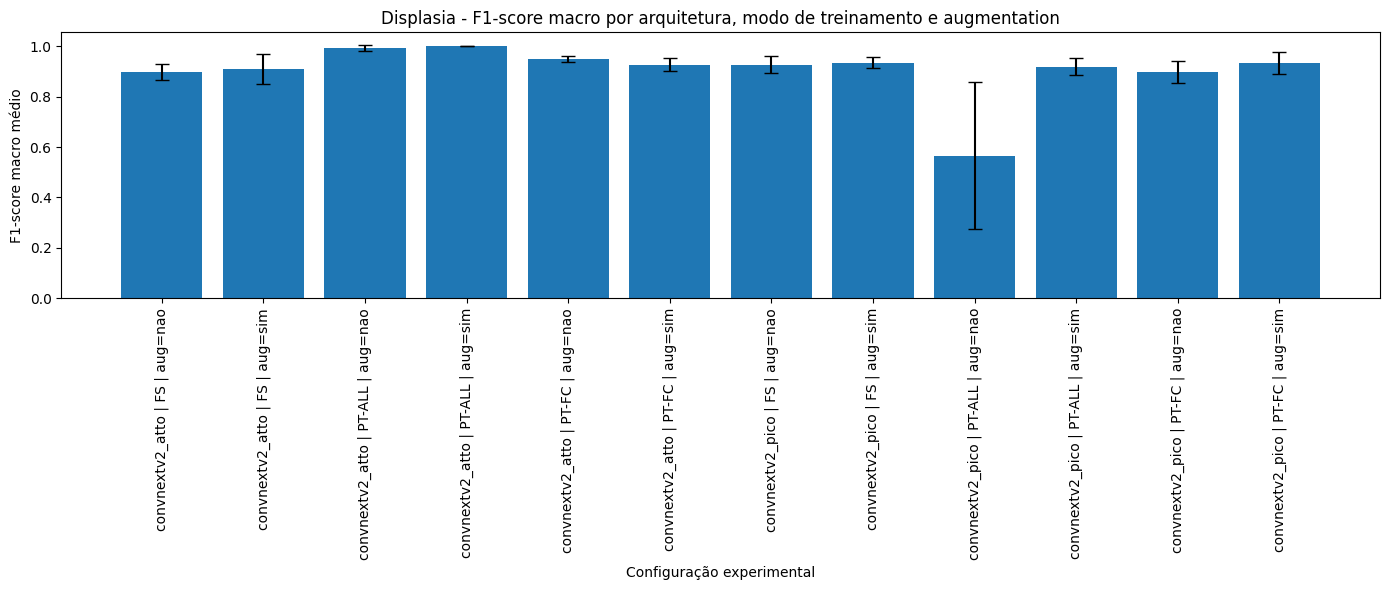

In [23]:
#Gráfico de barras do F1-score
grafico_f1 = tabela_resumo.copy()

grafico_f1["config"] = (
    grafico_f1["model"] + " | " +
    grafico_f1["training_mode"] + " | aug=" +
    grafico_f1["augmentation"].astype(str)
)

plt.figure(figsize=(14, 6))
plt.bar(grafico_f1["config"], grafico_f1["f1_macro_mean"], yerr=grafico_f1["f1_macro_std"], capsize=5)
plt.xticks(rotation=90)
plt.ylabel("F1-score macro médio")
plt.xlabel("Configuração experimental")
plt.title("Displasia - F1-score macro por arquitetura, modo de treinamento e augmentation")
plt.tight_layout()
plt.savefig("/content/figuras_displasia/f1_score_global_displasia.pdf")
plt.show()

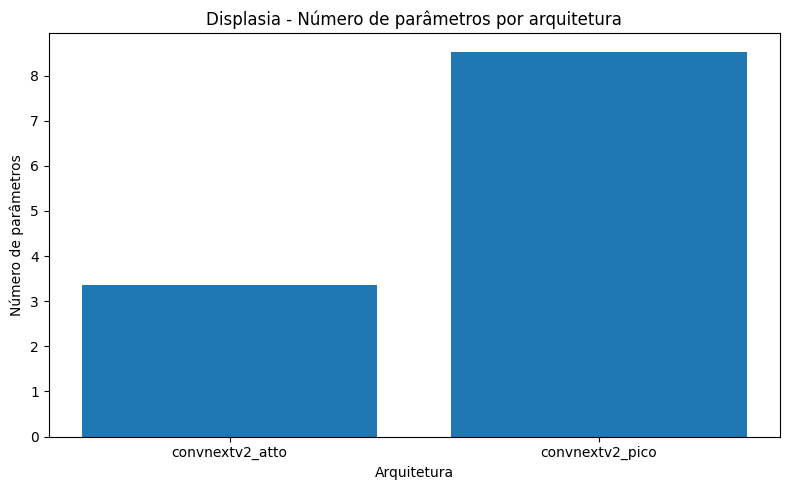

In [24]:
#Gráfico de número de parâmetros por arquitetura
params_por_modelo = (
    df_displasia
    .groupby("model")["num_params"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.bar(params_por_modelo["model"], params_por_modelo["num_params"])
plt.ylabel("Número de parâmetros")
plt.xlabel("Arquitetura")
plt.title("Displasia - Número de parâmetros por arquitetura")
plt.tight_layout()
plt.savefig("/content/figuras_displasia/parametros_por_arquitetura_displasia.pdf")
plt.show()

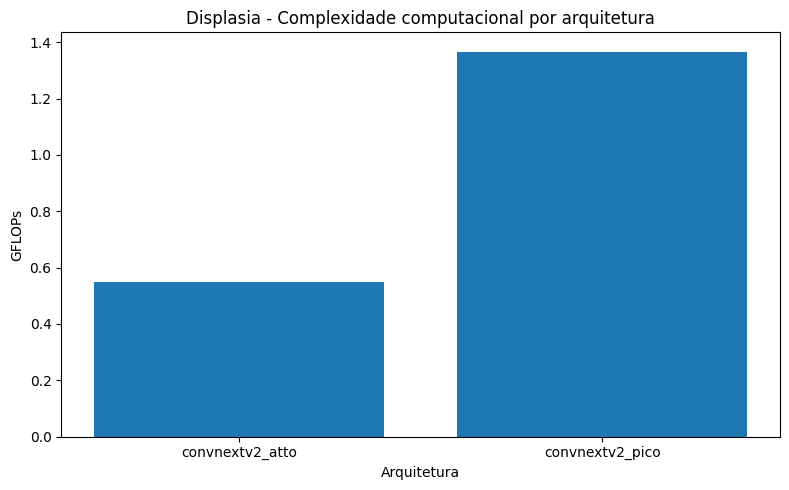

In [25]:
#Gráfico de GFLOPs por arquitetura
gflops_por_modelo = (
    df_displasia
    .groupby("model")["gflops"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.bar(gflops_por_modelo["model"], gflops_por_modelo["gflops"])
plt.ylabel("GFLOPs")
plt.xlabel("Arquitetura")
plt.title("Displasia - Complexidade computacional por arquitetura")
plt.tight_layout()
plt.savefig("/content/figuras_displasia/gflops_por_arquitetura_displasia.pdf")
plt.show()

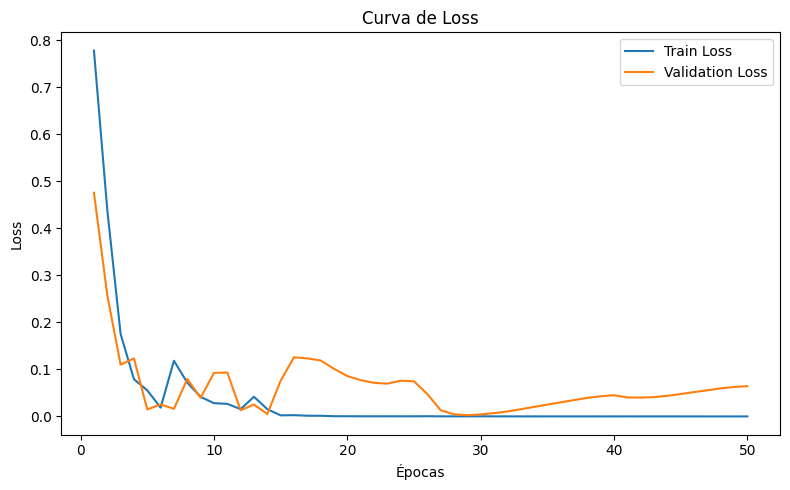

In [29]:
import json
import matplotlib.pyplot as plt

with open("/content/convnextv2_atto_PT-ALL_aug_seed42_history.json", "r") as f:
    history = json.load(f)

epochs = range(1, len(history["train_loss"]) + 1)

# LOSS
plt.figure(figsize=(8,5))

plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")

plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Curva de Loss")
plt.legend()

plt.tight_layout()
plt.savefig("/content/curva_loss.pdf")

plt.show()

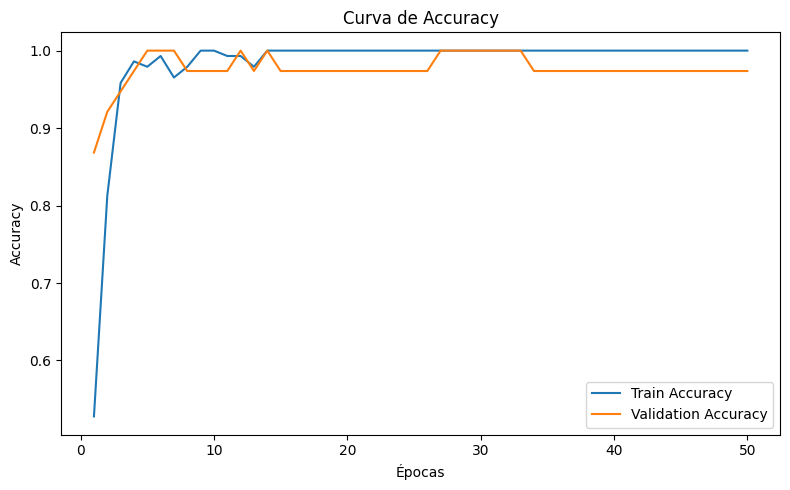

In [30]:
plt.figure(figsize=(8,5))

plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Validation Accuracy")

plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.title("Curva de Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("/content/curva_accuracy.pdf")

plt.show()

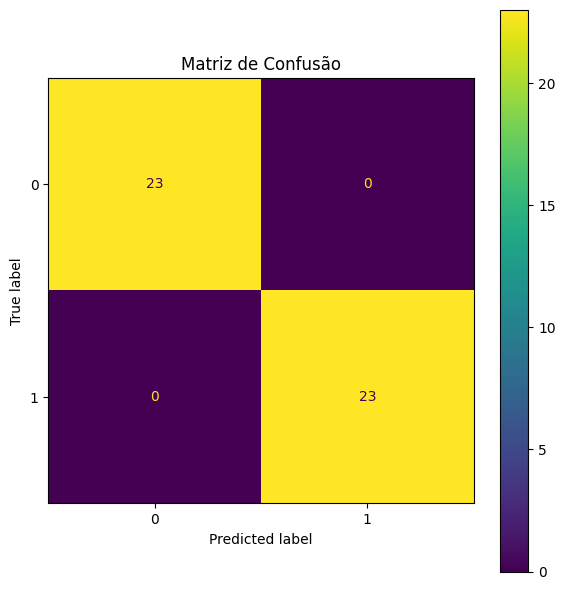

In [31]:
import json
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

with open("/content/convnextv2_atto_PT-ALL_aug_seed42_predictions.json", "r") as f:
    preds = json.load(f)

y_true = preds["y_true"]
y_pred = preds["y_pred"]

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(ax=ax)

plt.title("Matriz de Confusão")

plt.tight_layout()
plt.savefig("/content/matriz_confusao.pdf")

plt.show()

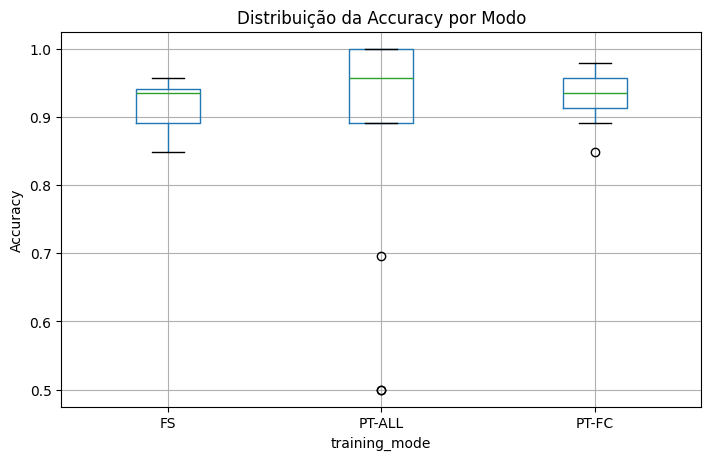

In [32]:
import matplotlib.pyplot as plt

df_displasia.boxplot(column="acc_test", by="training_mode", figsize=(8,5))

plt.title("Distribuição da Accuracy por Modo")
plt.suptitle("")
plt.ylabel("Accuracy")

plt.show()

In [33]:
tabela_final = (
    df_displasia
    .groupby(["model", "training_mode", "augmentation"])
    .agg({
        "acc_test": ["mean", "std"],
        "f1_macro_test": ["mean", "std"],
        "f1_weighted_test": ["mean", "std"]
    })
)

tabela_final

acc_test           f1_macro_test  \
                                                mean       std          mean   
model           training_mode augmentation                                     
convnextv2_atto FS            nao           0.898551  0.033207      0.898441   
                              sim           0.913043  0.057516      0.911721   
                PT-ALL        nao           0.992754  0.012551      0.992750   
                              sim           1.000000  0.000000      1.000000   
                PT-FC         nao           0.949275  0.012551      0.949238   
                              sim           0.927536  0.025102      0.927454   
convnextv2_pico FS            nao           0.927536  0.033207      0.927261   
                              sim           0.934783  0.021739      0.934441   
                PT-ALL        nao           0.657609  0.206522      0.566500   
                              sim           0.920290  0.033207      0.919774   
                PT-FC         nao           0.898551  0.045254      0.898213   
                              sim           0.934783  0.043478      0.934669   

                                                     f1_weighted_test  \
                                                 std             mean   
model           training_mode augmentation                              
convnextv2_atto FS            nao           0.033304         0.898441   
                              sim           0.059478         0.911721   
                PT-ALL        nao           0.012557         0.992750   
                              sim           0.000000         1.000000   
                PT-FC         nao           0.012545         0.949238   
                              sim           0.025102         0.927454   
convnextv2_pico FS            nao           0.033394         0.927261   
                              sim           0.022029         0.934441   
                PT-ALL        nao           0.290954         0.566500   
                              sim           0.033750         0.919774   
                PT-FC         nao           0.045077         0.898213   
                              sim           0.043499         0.934669   

                                                      
                                                 std  
model           training_mode augmentation            
convnextv2_atto FS            nao           0.033304  
                              sim           0.059478  
                PT-ALL        nao           0.012557  
                              sim           0.000000  
                PT-FC         nao           0.012545  
                              sim           0.025102  
convnextv2_pico FS            nao           0.033394  
                              sim           0.022029  
                PT-ALL        nao           0.290954  
                              sim           0.033750  
                PT-FC         nao           0.045077  
                              sim           0.043499

In [34]:
tabela_formatada = tabela_final.copy()

for metrica in ["acc_test", "f1_macro_test", "f1_weighted_test"]:

    tabela_formatada[(metrica, "resultado")] = (
        tabela_formatada[(metrica, "mean")].round(3).astype(str)
        + " ± " +
        tabela_formatada[(metrica, "std")].round(3).astype(str)
    )

tabela_formatada = tabela_formatada[[
    ("acc_test", "resultado"),
    ("f1_macro_test", "resultado"),
    ("f1_weighted_test", "resultado")
]]

tabela_formatada.columns = [
    "Accuracy",
    "F1 Macro",
    "F1 Weighted"
]

tabela_formatada

Accuracy       F1 Macro  \
model           training_mode augmentation                                 
convnextv2_atto FS            nao           0.899 ± 0.033  0.898 ± 0.033   
                              sim           0.913 ± 0.058  0.912 ± 0.059   
                PT-ALL        nao           0.993 ± 0.013  0.993 ± 0.013   
                              sim               1.0 ± 0.0      1.0 ± 0.0   
                PT-FC         nao           0.949 ± 0.013  0.949 ± 0.013   
                              sim           0.928 ± 0.025  0.927 ± 0.025   
convnextv2_pico FS            nao           0.928 ± 0.033  0.927 ± 0.033   
                              sim           0.935 ± 0.022  0.934 ± 0.022   
                PT-ALL        nao           0.658 ± 0.207  0.567 ± 0.291   
                              sim            0.92 ± 0.033   0.92 ± 0.034   
                PT-FC         nao           0.899 ± 0.045  0.898 ± 0.045   
                              sim           0.935 ± 0.043  0.935 ± 0.043   

                                              F1 Weighted  
model           training_mode augmentation                 
convnextv2_atto FS            nao           0.898 ± 0.033  
                              sim           0.912 ± 0.059  
                PT-ALL        nao           0.993 ± 0.013  
                              sim               1.0 ± 0.0  
                PT-FC         nao           0.949 ± 0.013  
                              sim           0.927 ± 0.025  
convnextv2_pico FS            nao           0.927 ± 0.033  
                              sim           0.934 ± 0.022  
                PT-ALL        nao           0.567 ± 0.291  
                              sim            0.92 ± 0.034  
                PT-FC         nao           0.898 ± 0.045  
                              sim           0.935 ± 0.043

In [35]:
tabela_formatada.to_csv(
    "/content/tabela_media_desvio_formatada.csv"
)

CURVAS/MATRIZES

In [37]:
melhor = df_displasia.sort_values(
    "acc_test",
    ascending=False
)

melhor.head(3)



,seed,dataset,model,training_mode,augmentation,acc_test,f1_macro_test,f1_weighted_test,num_params,gflops,best_epoch,val_acc_best
17,2025,Displastia,convnextv2_atto,PT-ALL,nao,1.0,1.0,1.0,3.368362,0.547029,3,1.0
13,123,Displastia,convnextv2_atto,PT-ALL,sim,1.0,1.0,1.0,3.368362,0.547029,5,1.0
14,2025,Displastia,convnextv2_atto,PT-ALL,sim,1.0,1.0,1.0,3.368362,0.547029,3,1.0


In [38]:
pior = df_displasia.sort_values(
    "acc_test",
    ascending=True
)

pior.head(3)



,seed,dataset,model,training_mode,augmentation,acc_test,f1_macro_test,f1_weighted_test,num_params,gflops,best_epoch,val_acc_best
34,42,Displastia,convnextv2_pico,PT-ALL,nao,0.500000,0.333333,0.333333,8.522818,1.36657,4,0.842105
33,42,Displastia,convnextv2_pico,PT-ALL,nao,0.500000,0.333333,0.333333,8.522818,1.36657,4,0.842105
35,123,Displastia,convnextv2_pico,PT-ALL,nao,0.695652,0.664583,0.664583,8.522818,1.36657,13,0.894737


In [39]:
mediana = df_displasia.iloc[
    len(df_displasia)//2
]

mediana

,18
seed,42
dataset,Displastia
model,convnextv2_pico
training_mode,FS
augmentation,sim
acc_test,0.913043
f1_macro_test,0.912381
f1_weighted_test,0.912381
num_params,8.522818
gflops,1.36657


# Relatorio 2 - Discussão Final

Os resultados obtidos no dataset Displasia demonstraram que as diferentes configurações experimentais impactaram significativamente o desempenho dos modelos avaliados.

De maneira geral, observou-se que o uso de Data Augmentation contribuiu positivamente para a capacidade de generalização das redes neurais, resultando em melhorias consistentes nas métricas de avaliação. Esse comportamento indica que o aumento artificial da variabilidade das imagens auxiliou os modelos na extração de padrões mais robustos e menos dependentes de características específicas do conjunto de treinamento.

Entre as arquiteturas avaliadas, a ConvNeXtV2 Atto apresentou os melhores resultados médios de desempenho, superando a ConvNeXtV2 Pico em praticamente todas as configurações analisadas. Além disso, a arquitetura Atto também apresentou menor custo computacional em termos de parâmetros e GFLOPs, demonstrando uma relação favorável entre desempenho e eficiência computacional.

Os experimentos também mostraram diferenças importantes entre os modos de treinamento. O modo PT-FC apresentou maior estabilidade média em comparação ao PT-ALL, comportamento que pode estar relacionado à ocorrência de overfitting durante o fine-tuning completo. Esse cenário é relativamente comum em aplicações de visão computacional médica, especialmente quando os datasets possuem tamanho reduzido.

Outro ponto relevante foi a presença de execuções com desempenho significativamente inferior em determinadas configurações experimentais, principalmente envolvendo a arquitetura ConvNeXtV2 Pico no modo PT-ALL sem augmentation. Esses resultados sugerem possíveis dificuldades de convergência e maior sensibilidade às variações aleatórias do treinamento.

De forma geral, os resultados obtidos indicam que o dataset Displasia apresentou boa separação entre as classes avaliadas, uma vez que diversas execuções alcançaram métricas próximas de 1.000. Ainda assim, a análise das curvas de aprendizado e das matrizes de confusão demonstrou que determinadas configurações permanecem suscetíveis à instabilidade e ao overfitting.

Por fim, os experimentos evidenciam a importância da escolha adequada da arquitetura, do modo de treinamento e do uso de técnicas de augmentation em problemas de classificação histológica, mostrando que modelos mais leves e estáveis podem alcançar desempenho superior mesmo com menor custo computacional.